# Лабораторная работа 2

## Линейная регрессия

### Метод наименьших квадратов: постановка задачи

Рассмотрим систему уравнений $Xa = y$, в которой $a$ — столбец неизвестных. Её можно переписать в векторном виде
$$x_1 a_1 + x_2 a_2 + \ldots + x_k a_k = y,$$
где $x_1,\ldots,x_k$ — столбцы матрицы $X$. Таким образом, решить исходную систему означает найти линейную комбинацию векторов $x_1,\ldots,x_k$, равную правой части. Но что делать, если такой линейной комбинации не существует? Геометрически это означает, что вектор $y$ не лежит в подпространстве $U = \langle x_1,\ldots, x_k\rangle$. В этом случае мы можем найти *псевдорешение*: вектор коэффициентов $\hat{a}$, для которого линейная комбинация $x_1 \hat{a}_1 + x_2 \hat{a}_2 + \ldots + x_k \hat{a}_k$ хоть и не равна в точности $y$, но является наилучшим приближением — то есть ближайшей к $y$ точкой $\hat{y}$ подпространства $U$ (иными словами, ортогональной проекцией $y$ на это подпростанство). Итак, цель наших исканий можно сформулировать двумя эквивалентными способами:

1. Найти вектор $\hat{a}$, для которого длина разности $|X\hat{a} - y|$ минимальна (отсюда название "метод наименьших квадратов");
2. Найти ортогональную проекцию $\hat{y}$ вектора $y$ на подпространство $U$ и представить её в виде $X\hat{a}$.

Далее мы будем предполагать, что векторы $x_1,\ldots,x_k$ линейно независимы (если нет, то сначала имеет смысл выделить максимальную линейно независимую подсистему).
На лекциях было показано, что в этом случае проекция вектора $y$ на подпространство $U = \langle x_1,\ldots, x_k\rangle$ записывается в виде
$$\hat{y} = X\left(X^TX\right)^{-1}X^Ty$$
и, соответственно, искомый вектор $\hat{a}$ равен
$$\hat{a} = \left(X^TX\right)^{-1}X^Ty.$$

### Задача линейной регрессии

Начнём с примера. Допустим, вы хотите найти зависимость среднего балла S студента ФКН от его роста H, веса W, длины волос L и N — количества часов, которые он ежедневно посвящает учёбе. Представьте, что мы измерили все эти параметры для $n$ студентов и получили наборы значений: $S_1,\ldots, S_n$, $H_1,\ldots, H_n$ и так далее.

Тут можно подбирать много разных умных моделей, но начать имеет смысл с самой простой, линейной:
$$S = a_1H + a_2W + a_3L + a_4N + a_5.$$
Конечно, строгой линейной зависимости нет (иначе можно было бы радостно упразднить экзамены), но мы можем попробовать подобрать коэффициенты $a_1, a_2, a_3, a_4, a_5$, для которых отклонение правой части от наблюдаемых было бы наименьшим:
$$\sum_{i=1}^n\left(S_i - ( a_1H_i + a_2W_i + a_3L_i + a_4N_i + a_5)\right)^2 \longrightarrow \min$$
И сразу видно, что мы получили задачу на метод наименьших квадратов! А именно, у нас
$$X =
\begin{pmatrix}
H_1 & W_1 & L_1 & N_1 & 1\\
H_2 & W_2 & L_2 & N_2 & 1\\
\dots & \dots & \dots & \dots & \dots \\
H_n & W_n & L_n & N_n & 1
\end{pmatrix},\qquad y=
\begin{pmatrix}
S_1\\ S_2\\ \vdots \\ S_n
\end{pmatrix}$$

Решая эту задачу с помощью уже известных формул, получаем оценки коэффициентов $\hat{a}_i$ ($i = 1\ldots,5$).

Теперь проговорим общую постановку задачи линейной регрессии. У нас есть $k$ переменных $x_1,\ldots,x_k$ ("регрессоров"), через которые мы хотим выразить "объясняемую переменную" $y$:
$$y = a_1x_1 + a_2x_2 + \ldots + a_kx_k.$$
Значения всех переменных мы измерили $n$ раз (у $n$ различных объектов,  в $n$ различных моментов времени — это зависит от задачи). Подставим эти данные в предыдущее равенство:
$$\begin{pmatrix}
y_1\\ y_2 \\ \vdots \\ y_n
\end{pmatrix} =
a_1\begin{pmatrix}
x_{11} \\ x_{21} \\ \vdots \\ x_{n1} \end{pmatrix} + a_2\begin{pmatrix}
x_{12} \\ x_{22} \\ \vdots \\ x_{n2} \end{pmatrix} + \ldots + a_k\begin{pmatrix}
x_{1k} \\ x_{2k} \\ \vdots \\ x_{nk} \end{pmatrix}$$
(здесь $x_{ij}$ — это значение $j$-го признака на $i$-м измерении). Это удобно переписать в матричном виде:
$$\begin{pmatrix}
x_{11} & x_{12} & \ldots & x_{1k}\\
x_{21} & x_{22} & \ldots & x_{2k}\\
\dots & \dots & \dots & \dots\\
x_{n1} & x_{n2} & \ldots & x_{nk}
\end{pmatrix} \cdot
\begin{pmatrix}
a_1 \\ a_2 \\ \vdots \\ a_k
\end{pmatrix} =
\begin{pmatrix}
y_1 \\ y_2 \\ \vdots \\ y_n
\end{pmatrix}$$
или коротко $Xa = y$. Поскольку на практике эта система уравнений зачастую не имеет решения (ибо зависимости в жизни редко бывают действительно линейными), методом наименьших квадратов ищется псевдорешение.

### Оценка качества. Обучение и тест

После того как вы построили регрессию и получили какую-то зависимость объясняемой переменной от регрессоров, настаёт время оценить качество регрессии. Есть много разных функционалов качества; мы пока будем говорить только о самом простом и очевидном из них: о среднеквадратичной ошибке (mean square error). Она равна
$$\frac1{n}|X\hat{a} - y|^2 = \frac1{n}\sum_{i=1}^n\left(\hat{a}_1x_{i1} + \hat{a}_2x_{i2} + \ldots + \hat{a}_kx_{ik} - y_i\right)^2.$$

В целом хочется искать модели с наименьшей mean square error на имеющихся данных. Однако слишком фанатичная гонка за минимизацией ошибки может привести к печальным последствиям, в чём вам предстоит убедиться в ходе выполнения этой лабораторной.

Чтобы не попадать в эту ловушку, данные обычно делят на обучающие (по которым строят модель и оценивают коэффициенты) и тестовые. Лучшей стоит счесть ту модель, для которой значение функционала качества будет меньше.

### Правила оформления графиков
При работе с данными часто неудобно делать какие-то выводы, если смотреть на таблицу и числа в частности, поэтому важно уметь визуализировать данные.

У matplotlib, конечно же, есть [документация](https://matplotlib.org/users/index.html) с большим количеством [примеров](https://matplotlib.org/examples/), но для начала достаточно знать про несколько основных типов графиков:
- plot — обычный поточечный график, которым можно изображать кривые или отдельные точки;
- hist — гистограмма, показывающая распределение некоторой величины;
- scatter — график, показывающий взаимосвязь двух величин;
- bar — столбцовый график, показывающий взаимосвязь количественной величины от категориальной.

Ещё одна библиотека для визуализации: [seaborn](https://jakevdp.github.io/PythonDataScienceHandbook/04.14-visualization-with-seaborn.html). Это надстройка над matplotlib, иногда удобнее и красивее делать визуализации через неё.

При выполнении этой лабораторной вы столкнётесь с необходимостью рисовать большое количество графиков. Не забывайте про базовые принципы построения приличных графиков:
- оси должны быть подписаны, причём не слишком мелко;
- у графика должно быть название;
- если изображено несколько графиков, то необходима поясняющая легенда;
- для точек из разных выборок необходимо использовать разные цвета;
- все линии на графиках должны быть чётко видны (нет похожих цветов или цветов, сливающихся с фоном);
- если отображена величина, имеющая очевидный диапазон значений (например, проценты могут быть от 0 до 100), то желательно масштабировать ось на весь диапазон значений (исключением является случай, когда вам необходимо показать малое отличие, которое незаметно в таких масштабах).

Помните, что проверяющий имеет право снизить оценку за неопрятные графики.

### Формат сдачи
Задания сдаются через систему Anytask. Инвайт можно найти на странице курса. Присылать необходимо ноутбук с выполненным заданием. Сам ноутбук называйте в формате homework-practice-02-linregr-Username.ipynb, где Username — ваша фамилия.

### Задание 1. Метод наименьших квадратов (3 балла)

Скачайте файлы ``train.txt`` и ``test.txt``. В первом из них находится обучающая выборка, а во втором — тестовая. Каждый из файлов содержит два столбца чисел, разделённых пробелами: в первом — $n$ точек (значения аргумента $x$), во втором — значения некоторой функции $y = f(x)$ в этих точках, искажённые случайным шумом. Ваша задача — по обучающей выборке подобрать функцию $y = g(x)$, пристойно приближающую неизвестную вам зависимость.

Загрузим обучающие и тестовые данные (не забудьте ввести правильный путь!).

In [ ]:
import numpy as np

data_train = np.loadtxt('train.txt', delimiter=',')
data_test = np.loadtxt('test.txt', delimiter=',')

**0. [0 баллов]** Разделим значения $x$ и $y$:

In [ ]:
X_train = data_train[:,0]
y_train = data_train[:,1]

X_test = data_test[:,0]
Y_test = data_test[:,1]

**1. [0.1 балла]** Найдите с помощью метода наименьших квадратов линейную функцию ($y = kx + b$), наилучшим образом приближающую неизвестную зависимость. Полезные функции: ``numpy.ones(n)`` для создания массива из единиц длины $n$ и ``numpy.concatenate((А, В), axis=1)`` для слияния двух матриц по столбцам (пара ``А`` и ``В`` превращается в матрицу ``[A B]``). Напечатайте этот многочлен в виде $kx+b$.

In [ ]:
import scipy.linalg as sla
import numpy as np

A = np.ones(X_train.size)
A = A.reshape(X_train.size, 1)
X = X_train.reshape(X_train.size, 1)
Y = y_train.reshape(X_train.size, 1)
train = np.concatenate((X, A), axis = 1)
p = np.dot(train.T, train)
ans = sla.inv(p)
p1 = np.dot(ans, train.T)
res = np.dot(p1,y_train)
print(res[0], 'x +', res[1])

2.2791344980519455 x + 4.433230905064934


**2. [0.15 балла]** Нарисуйте на плоскости точки $(x_i, y_i)$ из обеих выборок и полученную линейную функцию.

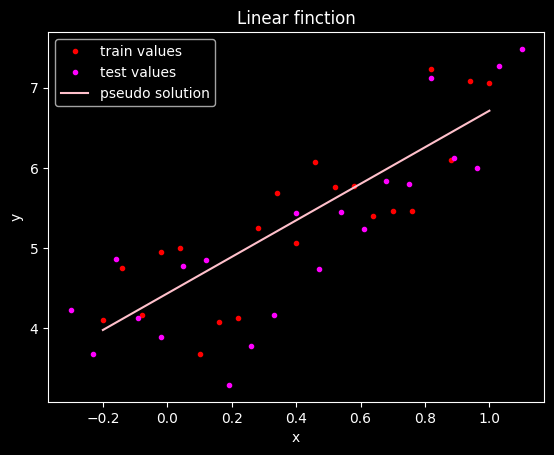

In [ ]:
import scipy.linalg as sla
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('dark_background')

k = res[0]
b = res[1]
X_train.reshape(X_train.size)
X_test = X_test.reshape(X_test.size, 1)
Y_test = Y_test.reshape(X_test.size, 1)
Y_res = k*X_train + b
plt.plot(X_train, y_train, ".",color='red', label='train values')
plt.plot(X_test, Y_test, ".", color='magenta', label='test values')
plt.plot(X_train, Y_res, color='pink', label='pseudo solution')
plt.title('Linear finction')
plt.ylabel('y')
plt.xlabel('x')
plt.legend()
plt.show()

**3. [0.15 балла]** Глядя на данные, подумайте, многочленом какой степени можно было бы лучше всего приблизить эту функцию с точки зрения минимизации среднеквадратичной ошибки на обучающей выборке. Найдите этот многочлен и напечатайте его в виде $a_0 + a_1 x + \ldots a_k x^k$. Для простоты кода можете использовать библиотеку [sympy](https://).

Для минимизации среднеквадратичной ошибки на обучающей выборке вероятнее всего стоит использовать многочлен c наименьшей ошибкой на обучающей выборке. Проверив ее значение в пункте 1.6, получается, что при k = 12 ошибка равна 0.07, далее она возрастает. Таким образом, используем 12ю степень

In [ ]:
def make_matrix(k, X):
    cur = np.copy(X)
    train = np.concatenate((X, A), axis = 1)
    res = np.copy(train)
    n = X.shape[0]
    for i in range(k-1):
        for j in range(n):
            cur[j] = cur[j] * X[j]
        res = np.concatenate((cur, res), axis = 1)
    return res

In [ ]:
def get_coefficients(mtx):
    mult = np.dot(mtx.T, mtx)
    inv_mult = sla.inv(mult)
    train_res = np.dot(np.dot(inv_mult, mtx.T), y_train)
    return train_res

In [ ]:
def updated_f(x):
    cur = 1
    res = 0
    for c in coeff:
        res += c * cur
        cur *= x
    return res

In [ ]:
mtx = make_matrix(12, X)
coeff = get_coefficients(mtx)
print("Polynomial: ", end="")
coeff = coeff[::-1]
for i in range(len(coeff)):
    if i == 0:
          print(f"{coeff[i]:.2f}", end="")
    elif i == 1:
        if coeff[i]>=0:
            print(f" + {coeff[i]:.2f}x", end="")
        else:
            print(f" {coeff[i]:.2f}x", end="")
    else:
        if coeff[i] >= 0:
            print(f" + {coeff[i]:.2f}x^{i}", end="")
        else:
            print(f" {coeff[i]:.2f}x^{i}", end="")

Polynomial: 5.21 -2.27x -251.99x^2 + 813.51x^3 + 11876.28x^4 -67439.89x^5 -10669.13x^6 + 984605.56x^7 -3416689.04x^8 + 5729941.05x^9 -5314210.03x^10 + 2618818.22x^11 -536790.26x^12

**4. [0.1 балла]** Нарисуйте его график на одном чертеже вместе с точками $(x_i, y_i)$ из обеих выборок.

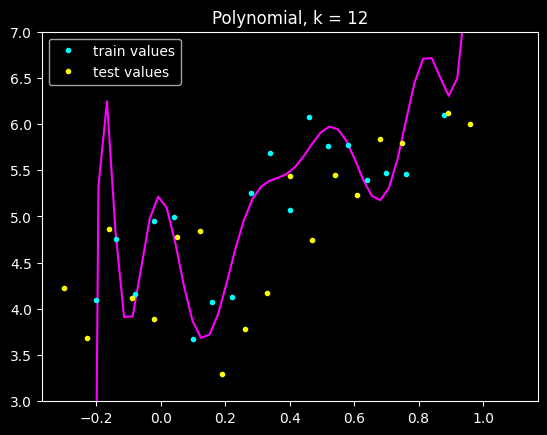

In [ ]:
plt.style.use('dark_background')
x = np.linspace(-0.3, 1.0);
y = updated_f(x);
plt.plot(x, y, color='magenta')
plt.title('Polynomial, k = 12')
plt.ylim([3, 7])
plt.plot(X_train, y_train,".", color='cyan', label='train values')
plt.plot(X_test, Y_test, ".", color='yellow', label='test values')
plt.legend()
plt.show()

**5. [0.25 балла]** Для $k = 1,2,3,\ldots,10$ найдите многочлен $\hat{f}_k$ степени $k$, наилучшим образом приближающий неизвестную зависимость. Напечатайте найденные многочлены в виде $a_0 + a_1 x + \ldots a_k x^k$.

In [ ]:
print("Polynomial:")
for k in range (1, 11):
    print()
    print("k =", k, ":")
    train_mtx = make_matrix(k, X)
    coeff = get_coefficients(train_mtx)
    coeff = coeff[::-1]
    for i in range(len(coeff)):
      if i == 0:
            print(f"{coeff[i]:.2f}")
      elif i == 1:
            if coeff[i]>=0:
                print(f" + {coeff[i]:.2f}x", end="")
            else:
                print(f" {coeff[i]:.2f}x", end="")
      else:
            if coeff[i] >= 0:
                print(f" + {coeff[i]:.2f}x^{i}", end="")
            else:
                print(f" {coeff[i]:.2f}x^{i}", end="")
    print()

Polynomial:

k = 1 :
4.43
 + 2.28x

k = 2 :
4.47
 + 1.16x + 1.40x^2

k = 3 :
4.46
 + 1.07x + 1.86x^2 -0.38x^3

k = 4 :
4.34
 + 1.17x + 6.79x^2 -13.05x^3 + 7.92x^4

k = 5 :
4.43
 -0.13x + 3.27x^2 + 21.37x^3 -51.13x^4 + 29.52x^5

k = 6 :
4.38
 -4.60x + 16.00x^2 + 121.26x^3 -481.51x^4 + 581.45x^5 -229.97x^6

k = 7 :
4.44
 -4.01x + 7.22x^2 + 119.35x^3 -314.23x^4 + 122.88x^5 + 238.70x^6 -167.38x^7

k = 8 :
4.66
 -5.18x -26.70x^2 + 268.86x^3 + 109.90x^4 -3132.86x^5 + 6760.63x^6 -5701.71x^7 + 1729.48x^8

k = 9 :
4.65
 -4.55x -24.26x^2 + 219.04x^3 + 176.25x^4 -2441.96x^5 + 3913.27x^6 -1216.45x^7 -1522.10x^8 + 903.22x^9

k = 10 :
4.67
 -2.16x -36.18x^2 + 44.93x^3 + 1201.96x^4 -1660.82x^5 -12970.03x^6 + 46686.92x^7 -63621.33x^8 + 40177.73x^9 -9818.63x^10


**6. [1 балл]** Для каждого из них найдите среднеквадратическую ошибку на обучающих данных и на тестовых данных: $\frac1{n}\sum_{i=1}^n\left( \hat{f}_k(x_i) - y_i \right)^2$ (в первом случае сумма ведётся по парам $(x_i, y_i)$ из обучающих данных, а во втором — по парам из тестовых данных).

In [ ]:
def counter(x):
    res = 0
    cnt = 1
    for i in coeffs[-1::-1]:
      res += i * cnt
      cnt *= x
    return res

def mse(x, y):
    X = np.copy(x)
    Y = np.copy(y)
    n = X.size
    res = 0
    for i in range(n):
        res += (counter(X[i]) - Y[i])**2
    return res/n

print("Mean square error:")
for k in range(1, 11):
    print()
    train_mtx = make_matrix(k, X)
    coeffs = get_coefficients(train_mtx)
    print("k =", k, ":")
    print("train:", mse(X, Y))
    print("test:", mse(X_test, Y_test))

Mean square error:

k = 1 :
train: [0.29689663]
test: [0.4351202]

k = 2 :
train: [0.26969892]
test: [0.35647629]

k = 3 :
train: [0.26949719]
test: [0.35534646]

k = 4 :
train: [0.26106653]
test: [0.44172702]

k = 5 :
train: [0.24998505]
test: [0.5579732]

k = 6 :
train: [0.18829349]
test: [2.58169293]

k = 7 :
train: [0.18539621]
test: [2.51578289]

k = 8 :
train: [0.15905557]
test: [4.35728982]

k = 9 :
train: [0.15847184]
test: [4.77640611]

k = 10 :
train: [0.15316613]
test: [14.63164946]


**7. [0.75 балла]** Для $k = 1,2,3,4,5,6$ нарисуйте графики полученных многочленов на одном чертеже вместе с точками $(x_i, y_i)$ из обеих выборок (возможно, график стоит сделать побольше; это делается командой `plt.figure(figsize=(width, height))`).

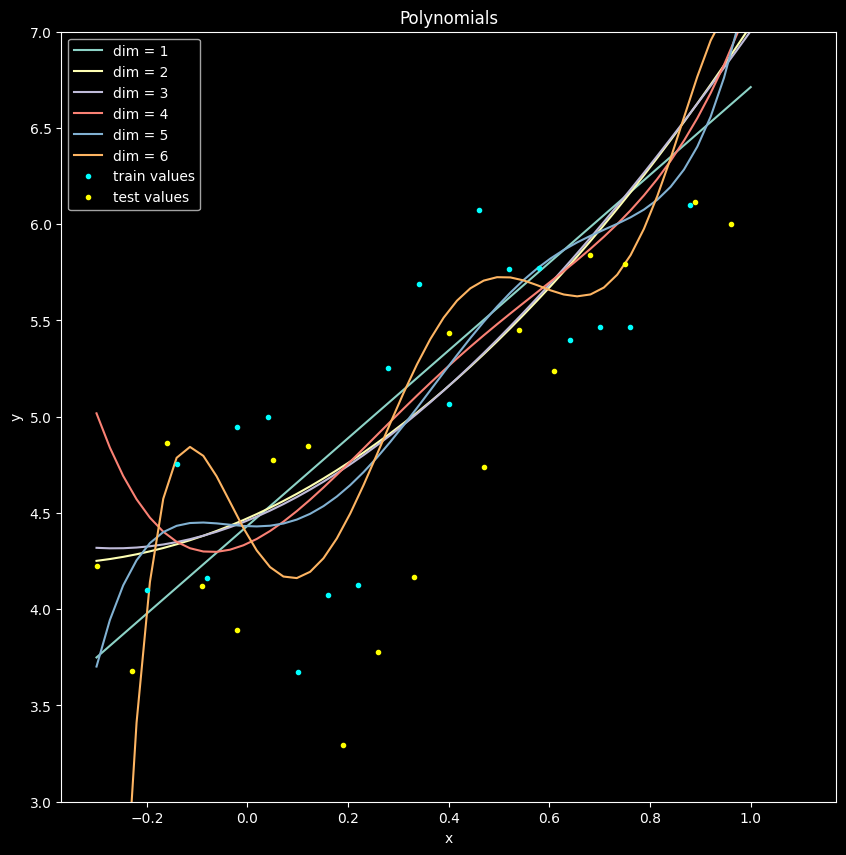

In [ ]:
def updated_f(x):
    cur = 1
    res = 0
    for c in coeff[::-1]:
        res += c * cur
        cur *= x
    return res
plt.figure(figsize=(10, 10))
cmap = plt.get_cmap('Pastel1')
for i in range(1, 7):
    mtx = make_matrix(i, X)
    coeff = get_coefficients(mtx)
    x = np.linspace(-0.3, 1.0);
    y = updated_f(x);
    plt.plot(x, y, label="dim = " + str(i))
plt.plot(X_train, y_train,".", color='cyan', label='train values')
plt.plot(X_test, Y_test, ".", color='yellow', label='test values')
plt.title('Polynomials')
plt.ylim([3, 7])
plt.ylabel('y')
plt.xlabel('x')
plt.legend()
plt.show()

**8. [0.5 балла]** Что происходит с ошибкой при росте степени многочлена? Казалось бы, чем больше степень, тем более сложным будет многочлен и тем лучше он будет приближать нашу функцию. Подтверждают ли это ваши наблюдения? Как вам кажется, чем объясняется поведение ошибки на тестовых данных при $k = 10$? Как, по вашему мнению, в машинном обучении называется наблюдаемый вами эффект?

С ростом степени многочлена ошибка на обучении обычно уменьшается, но на тесте после какого-то момента может начать расти, модель становится слишком сложной и подстраивается уже не под зависимость, а под шум в данных. Скорее всего, при k=10 как раз это и произошло. В машинном обучении такой эффект называется переобучением.

### Задание 2. Линейная регрессия (3.5 балла)

Скачайте файлы ``flats_moscow_mod.txt`` и ``flats_moscow_description.txt``. В первом из них содержатся данные о квартирах в Москве. Каждая строка содержит шесть характеристик некоторой квартиры, разделённые знаками табуляции; в первой строке записаны кодовые названия характеристик. Во втором файле приведены краткие описания признаков.

**0. [0 баллов]** Разделите выборку на обучающую и тестовую. Делать это лучше случайным образом (ведь вы не знаете, как создатели датасета упорядочили объекты); рекомендуем вам для этого функцию `sklearn.model_selection.train_test_split` с параметром `test_size=0.3`. Не забудьте зафиксировать параметр `random_state`.

In [ ]:
data = np.genfromtxt('flats_moscow_mod.txt',  delimiter='\t', skip_header=1, dtype=float)
X = data[:, 0]
y = data[:, 1 :]
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

**1. [0.5 балла]** Вашей задачей будет построить с помощью метода наименьших квадратов (линейную) зависимость между ценой квартиры и остальными доступными параметрами. С помощью известных вам формул найдите регрессионные коэффициенты. Выпишите построенную модель.

In [ ]:
import numpy as np
import scipy.linalg as sla
n = y_train.shape[0]
B =  np.ones(n)
B = B.reshape(1, n)
res = np.concatenate((y_train, B.T), axis = 1)
ans = np.dot(res.T, res)
inv = sla.inv(ans)
coeffs = np.dot(np.dot(inv, res.T), X_train)
print(coeffs)
print(coeffs[0], "+", coeffs[1], "*z_{totsp} +", coeffs[2], "y_{livesp} ", coeffs[3], "*m_{kitsp}", coeffs[4], "*x_{dist}",
      coeffs[5], "*l_{metrodist}")

[ 1.594975    1.06033898  2.06904991 -3.41198951 -1.38612153 -8.10090029]
1.5949749963768551 + 1.0603389771036198 *z_{totsp} + 2.06904991343493 y_{livesp}  -3.4119895138228196 *m_{kitsp} -1.3861215319193796 *x_{dist} -8.100900294760434 *l_{metrodist}


**2. [0.25 балла]** Какой смысл имеют их знаки? Согласуются ли они с вашими представлениями о жизни?

Знак коэффициента показывает направление влияния признака на цену квартиры. Положительный увеличивает цену, отрицательный уменьшает. Например, чем дальше квартира от центра, тем она обычно дешевле, а чем больше её площадь, тем дороже.

**3. [0.25 балла]** Оцените качество приближения, вычислив среднеквадратическую ошибку на тестовой выборке.

In [ ]:
print("Mean square error")
def cnt(X):
    sum = 0
    for i in range(X.size):
        sum += X[i]*coeffs[i]
    return sum
def mse(X, Y):
    sum = 0
    for i in range(Y.size):
        sum += (cnt(X[i]) - Y[i])**2
    return sum/Y.size
n = y_train.shape[0]
B =  np.ones(n)
B = B.reshape(1, n)
res = np.concatenate((y_train, B.T), axis = 1)
ans = np.dot(res.T, res)
inv = sla.inv(ans)
coeffs = np.dot(np.dot(inv, res.T), X_train)
print(mse(y_test, X_test))

Mean square error
1285.1439615794495


### Усложнение модели

Конечно, никто не гарантирует, что объясняемая переменная (цена квартиры) зависит от остальных характеристик именно линейно. Зависимость может быть, например, квадратичной или логарифмической; больше того, могут быть важны не только отдельные признаки, но и их комбинации. Это можно учитывать, добавляя в качестве дополнительных признаков разные функции от уже имеющихся характеристик: их квадраты, логарифмы, попарные произведения.

В этом задании вам нужно постараться улучшить качество модели, добавляя дополнительные признаки, являющиеся функциями от уже имеющихся. Но будьте осторожны: чрезмерное усложнение модели будет приводить к переобучению.

**4. [0.25 балла]** Опишите признаки, которые вы решили добавить. Объясните, чем был мотивирован выбор именно этих признаков.

Были добавлены три признака: логарифм по основанию 10 от общей площади, квадрат расстояния до центра и куб жилой площади квартиры. Первый признак введён, потому что цена, на мой взгляд, зависит от общей площади не линейно, те на небольших квартирах разница в цене часто не так заметна. Второй и третий признаки позволяют сильнее отразить влияние факторов, которые существенно связаны со стоимостью квартиры, а именно расположение и жилая площадь.

**5. [2 балла]** Постройте с помощью метода наименьших квадратов (линейную) зависимость между ценой квартиры и новыми признаками. С помощью известных вам формул найдите регрессионные коэффициенты. Выпишите построенную модель.

In [ ]:
from sklearn.model_selection import train_test_split
import math
import numpy as np
data = np.genfromtxt('flats_moscow_mod.txt',  delimiter='\t', skip_header=1, dtype=float)
X = data[:, 0]
y = data[:, 1 :]
X_train, X_test, y_train, y_test = train_test_split(y, X, test_size=0.3, random_state=42)
def pow(F, k):
    n = F.size
    F = F.reshape(1, n)
    NF = np.copy(F)
    NF = NF**k;
    return NF.T
def solve(mtx, prices):
    mult = np.dot(mtx.T, mtx)
    inv_mult = sla.inv(mult)
    coeffs = np.dot(np.dot(inv_mult, mtx.T), prices)
    return coeffs
def logg(X):
    for i in range(len(X)):
        X[i] = math.log(X[i], 10)
    return X
totsp = X_train.T[0]
livsp = X_train.T[1]
dist = X_train.T[3]
n = totsp.size
totsp_pow = logg(totsp).reshape(n, 1)
livsp_pow = pow(livsp, 3).reshape(n, 1)
dist_ln = pow(dist, 2).reshape(n, 1)
X_train = np.concatenate((totsp_pow, X_train), axis = 1)
X_train = np.concatenate((livsp_pow, X_train), axis = 1)
X_train = np.concatenate((dist_ln, X_train), axis = 1)
coefficients = solve(X_train, y_train)
print(coefficients)
print(coefficients[0], "*x^2_{dist} +", coefficients[1], "*y^3_{livesp} +", coefficients[2], "*ln(z)_{totsp}", coefficients[3], "*z_{totsp} +", coefficients[4], "y_{livesp}", coefficients[5], "*m_{kitsp}", coefficients[6], "*x_{dist} +",
      coefficients[7], "*l_{metrodist}")
totsp_tst = X_test.T[0]
livsp_tst = X_test.T[1]
dist_tst = X_test.T[3]
m = totsp_tst.size
totsp_tst_pow = logg(totsp_tst).reshape(m, 1)
livsp_tst_pow = pow(livsp_tst, 3).reshape(m, 1)
dist_tst_pow = pow(dist_tst, 2).reshape(m, 1)

[-2.72736194e+01  8.01484433e-03  5.03945817e+18 -3.19482008e+18
  3.19214974e+00 -1.53886305e+01 -2.27455552e+02  0.00000000e+00]
-27.273619353994697 *x^2_{dist} + 0.008014844328126852 *y^3_{livesp} + 5.039458171435603e+18 *ln(z)_{totsp} -3.1948200771948687e+18 *z_{totsp} + 3.192149735173082 y_{livesp} -15.388630521313559 *m_{kitsp} -227.45555159503027 *x_{dist} + 0.0 *l_{metrodist}


**6. [0.25 балла]** Оцените качество приближения, вычислив среднеквадратическую ошибку на тестовой выборке.

In [ ]:
def cnt(X):
    sum = 0
    for i in range(X.size):
        sum += X[i]*coefficients[i]
    return sum

def mse(X, Y):
    sum = 0
    for i in range(Y.size):
        sum += (cnt(X[i]) - Y[i])**2
    return sum/Y.size
X_test = np.concatenate((totsp_tst_pow,X_test), axis = 1)
X_test = np.concatenate((livsp_tst_pow,X_test), axis = 1)
X_test = np.concatenate((dist_tst_pow, X_test), axis = 1)
print(mse(X_test, y_test))

1.1757555207625367e+37


### Задание 3. Регуляризация (3.5 балла)

Вспомним, что задача линейной регрессии формулируется как задача нахождения проекции вектора значений объясняемой переменной $y$ на линейную оболочку $\langle x_1,\ldots,x_k\rangle$ векторов значений регрессоров. Если векторы $x_1,\ldots,x_k$ линейно зависимы, то матрица $X^TX$ вырожденна и задача не будет решаться с помощью приведённой выше формулы. В жизни, по счастью, различные признаки редко бывают *в точности* линейно зависимы, однако во многих ситуациях они скоррелированы и становятся "почти" линейно зависимыми. Таковы, к примеру, зарплата человека, его уровень образования, цена машины и суммарная площадь недвижимости, которой он владеет. В этом случае матрица $X^TX$ будет близка к вырожденной, и это приводит к численной неустойчивости и плохому качеству решений; как следствие, будет иметь место переобучение. Один из симптомов этой проблемы — необычно большие по модулю компоненты вектора $a$.

Есть много способов борьбы с этим злом. Один из них — регуляризация. Сейчас мы рассмотрим одну из её разновидностей — **L2-регуляризацию**. Идея в том, чтобы подправить матрицу $X^TX$, сделав её "получше". Например, это можно сделать, заменив её на $(X^TX + \lambda E)$, где $\lambda > 0$ — некоторый скаляр. Пожертвовав точностью на обучающей выборке, мы тем не менее получаем численно более стабильное псевдорешение $a = (X^TX + \lambda E)^{-1}X^Ty$ и снижаем эффект переобучения. *Гиперпараметр* $\lambda$ нужно подбирать, и каких-то универсальных способов это делать нет, но зачастую можно его подобрать таким, чтобы ошибка на тестовой выборке падала.

Однако есть некоторые правила, которых стоит придерживаться при подборе коэффициента регуляризации. Обычно в такой ситуации всю выборку делят на три части: обучающую, *валидационную* и тестовую. Сначала по валидационной подбирают значение гиперпараметра, потом по обучающей строят модель, а по тестовой оценивают её итоговое качество. Кроме того, подбирать $\lambda$ нужно по логарифметической сетке, чтобы узнать оптимальный порядок величины.

**1. [0.25 балла]** Почему не стоит подбирать коэффициент регуляризации по обучающей выборке? По тестовой выборке?

Если выбирать коэффициент регуляризации по обучающей выборке, это может привести к переобучению, те модель слишком сильно подстроится под обучающие данные и из-за этого будет хуже работать на новых. В результате ошибка на тестовой выборке может оказаться высокой.

Но подбирать коэффициент по тестовой выборке тоже неправильно, потому что тогда модель фактически настраивается уже под тестовые данные. Это может исказить оценку качества, ведь тестовая выборка нужна для итоговой проверки модели, а не для её настройки.

**2. [0 баллов]** Теперь давайте вспомним первую задачу. Если вы её сделали, то помните, что ошибка аппроксимации многочленом шестой степени довольно высокая. Попытаемся использовать регуляризацию при построении модели. Поделите обучающую выборку из первой задачи на две части, одну из которых объявите обучающей, а другую — валидационной (будьте осторожны при выборе `train_size`, в этой выборке не так много данных).

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
data_train = np.loadtxt('train.txt', delimiter=',')
data_test = np.loadtxt('test.txt', delimiter=',')
X_train = data_train[:,0]
y_train = data_train[:,1]
X_test = data_test[:,0]
y_test = data_test[:,1]
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, train_size=0.8, random_state=99)

**3. [0.75 балла]** Убедитесь, что, используя регуляризацию с хорошо подобранным коэффициентом $\lambda$, ошибку на тестовой выборке можно сделать не больше, чем для многочлена оптимальной степени в модели без регуляризации.

In [ ]:
X = np.array([np.ones(len(X_train))]).T
for k in range(1, 7):
    m = []
    for i in range(len(X_train)):
        m.append(X_train[i] ** k)
    column = np.array([m]).T
    X = np.concatenate((X, column), axis=1)
Y = np.array([y_train]).T
min_lambda = 1
s = 0.01
min_error = 1
for i in range(4):
    lambda_new = min_lambda
    for j in range(-49, 51):
        lambd = min_lambda + j * s
        a = sla.inv(X.T @ X + lambd * np.eye(7)) @ X.T @ Y
        mse = 0
        for i in range(len(X_val)):
            f_x = 0
            for coef in range(7):
                f_x += a[coef][0] * X_val[i] ** coef
            mse += (f_x - y_val[i]) ** 2
        error = mse / len(X_val)
        if error < min_error:
            min_error = error
            lambda_new = lambd
    min_lambda = lambda_new
    s /= 100

l = min_lambda
a = np.linalg.inv(X.T @ X + l * np.eye(7)) @ X.T @ Y
mse = 0
for i in range(len(X_test)):
    f_x = 0
    for coef in range(7):
        f_x += a[coef][0] * X_test[i] ** coef
    mse += (f_x - y_test[i]) ** 2
error = mse/len(X_test)
print("old error:", 0.3553464571518405)
print('new error:', error)
print("lambda =", l)

old error: 0.3553464571518405
new error: 0.31253368392282405
lambda = 0.50505051


**4. [0.25 балла]** Для этого $\lambda$ сравните $\det(X^TX)$ и $\det(X^TX + \lambda E)$. Теоретически объясните полученный результат, доказав, что $\det(X^TX+\lambda E) > 0$ при $\lambda>0$.

In [ ]:
import scipy.linalg as sla
X = np.array([np.ones(len(X_train))]).T
for k in range(1, 7):
    m = []
    for i in range(len(X_train)):
        m.append(X_train[i] ** k)
    column = np.array([m]).T
    X = np.concatenate((X, column), axis=1)
print(sla.det(sla.inv(X.T @ X)))
print(sla.det((sla.inv(X.T @ X + 0.50505051 * np.eye(7)))))

541266421708.60376
0.07491963762891397


**5. [0.25 балла]** Нарисуйте на одном чертеже графики многочленов шестой степени, приближающих неизвестную функцию, для модели с регуляризацией и без.

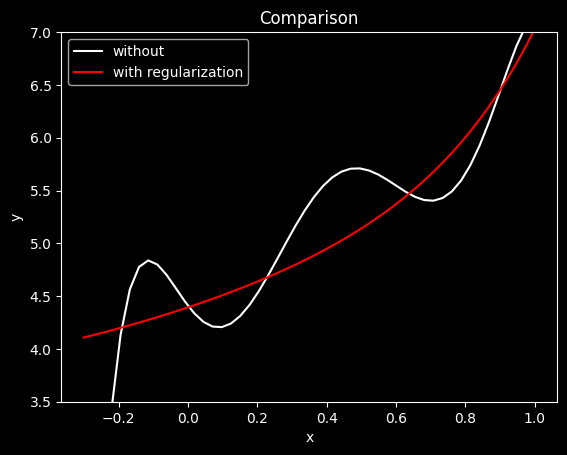

In [ ]:
def updated_f(x):
    cur = 1
    res = 0
    for c in coefficients:
        res += c * cur
        cur *= x
    return res
X = np.array([np.ones(len(X_train))]).T
for k in range(1, 7):
    m = []
    for i in range(len(X_train)):
       m.append(X_train[i] ** k)
    column = np.array([m]).T
    X = np.concatenate((X, column), axis=1)
Y = np.array([y_train]).T
mult = np.dot(X.T, X)
inv_mult = sla.inv(mult)
a = np.dot(np.dot(inv_mult, X.T), y_train)
coefficients = a.T
x = np.linspace(-0.3, 1);
y = updated_f(x);
plt.plot(x, y, color="white", label="without")
mult = np.dot(X.T, X)
inv_mult = sla.inv(mult +0.50505051 * np.eye(7))
a = np.dot(np.dot(inv_mult, X.T), y_train)
coefficients = a.T
y_1 = updated_f(x);
plt.ylim([3.5, 7])
plt.plot(x, y_1, color="red", label="with regularization")
plt.title('Comparison')
plt.ylabel('y')
plt.xlabel('x')
plt.legend()
plt.show()

**6. [0.25 балла]** Чем первый из них выгодно отличается от второго?

Первый не учитывает колебания обучающих данных, сглаживая все изгибы кривой шестой степени. Это позволяет избежать эффекта переобучения на тестовых данных, а также строит модель в обшем случае. На обощенных данных мы получаем стабильное решение, отражающее неизвестную зависимость.

**7. [0.75 балла]** Пусть заданы $X\in \text{Mat}_{n \times k}(\mathbb{R})$ ($k \leqslant n$), $y \in \mathbb{R}^n$, $\lambda \geqslant 0$, а также известно, что $\text{rk}~X = k$. Решите теоретически следующую задачу оптимизации:
$$|Xa - y|^2 + \lambda|a|^2\rightarrow\min\limits_{a \in \mathbb{R}^k}.$$
(То есть найдите все векторы $a \in \mathbb{R}^k$, для которых выражение слева принимает наименьшее возможное значение.) В частности, докажите существование решений и укажите их количество в зависимости от входных данных.


$$
|Xa - y|^2 + \lambda|a|^2
$$

$$
\frac{\delta}{\delta a} (|Xa -y|^2 + \lambda |a|^2) = 2X^T (Xa - y) + 2 \lambda a
$$

$$
X^Xa - X^Ty + \lambda a = 0
$$

$$
a = (X^T + \lambda E)^{-1} X^T y
$$

Так как $\lambda > 0$, матрица невырождена, а значит, решение всегда существует и единственно.


Интуитивно это можно понимать так: мы ищем компромисс между минимизацией длины разности $|Xa - y|$ (то есть точностью решения задачи регрессии) и тем, чтобы компоненты вектора $a$ не становились слишком большими по модулю.

**8. [0.25 балла]** Попробуйте объяснить, почему регуляризовать (штрафовать за слишком большую абсолютную величину) коэффициент при константном признаке (который состоит из одних единиц) — плохая идея.

Если штрафовать за коэффициент при единичном признаке, модель перестанет корректно центрировать предсказания. Это может привести к смещению модели.

**9. [0.5 балла]** Пусть теперь $\text{rk}~X < k$. Всегда ли в этом случае существует решение? Если существует, то является ли оно единственным? Ответ обоснуйте.

Если $rk X<k$, то $X^TX$ вырождена, а значит, не существует обратной матрицы. Однако при $\lambda > 0$, $\lambda E$ делает матрицу невырожденной, поэтому решение всегда существует.

**10. [0.25 балла]** Покажите теоретически, что если решений бесконечно много, то среди них обязательно найдутся решения со сколь угодно большими по модулю компонентами вектора $a$. Почему большие веса в линейной модели — плохо?

Если решений бесконечно много, можно получить $\vec{a}$ с очень большими по модулю компонентами. Это приведёт к двум случаям:
1. Нестабильная модель: малые изменения в данных дадут огромные изменения в предсказаниях.
2. Переобучение модели: модель будет сильно зависеть от тренировочной выборки.
Регуляризация решает эту проблему, ограничивая величину коэффициентов.

### Задание 4. Онлайн-обучение линейной регрессии (3 балла)

Раньше мы работали в ситуации, когда объекты $x_i$ и значения $y_i$ даны с самого начала и всегда доступны. Допустим теперь, что пары $(x_i, y_i)$ поступают к нам по одной и мы не можем себе позволить хранить их все в памяти (это может быть актуально, например, если вы пытаетесь обучить модель на устройстве со сравнительно небольшим количеством оперативной памяти: скажем, на мобильном телефоне или на бортовом компьютере спутника связи). В этом случае нам нужно уметь решать следующую задачу:

**Известно:** решение задачи регрессии для датасета $(x_1, y_1),\ldots,(x_t,y_t)$;

**На вход поступает:** новая пара $(x_{t+1}, y_{t+1})$;

**Требуется:** быстро (за время, не зависящее от $t$) отыскать решение задачи регрессии для расширенного датасета $(x_1, y_1),\ldots,(x_t,y_t),(x_{t+1}, y_{t+1})$.

Обозначим $X_{(t)} = (x_1\ldots x_t)^T$ и $y_{(t)} = (y_1,\ldots,y_t)^T$. Тогда, как мы хорошо помним, решение задачи регрессии для датасета $(x_1, y_1),\ldots,(x_t,y_t)$ имеет вид $\hat{a}_{(t)} = \left(X^T_{(t)}X_{(t)}\right)^{-1}X^T_{(t)}y_{(t)}$. Размеры матриц $X^T_{(t)}X_{(t)}$ и $X^T_{(t)}y_{(t)}$ не зависят от $t$, поэтому их мы, пожалуй, можем себе позволить хранить в памяти.

**1. [1 балл]** И вот ваше первое задание в этом разделе: придумайте алгоритм, принимающий на вход матрицы $X^T_{(t)}X_{(t)}$ и $X^T_{(t)}y_{(t)}$, а также пару $(x_{t+1}, y_{t+1})$, и вычисляющий матрицы $X^T_{(t+1)}X_{(t+1)}$ и $X^T_{(t+1)}y_{(t+1)}$. Сложность вашего алгоритма не должна зависеть от $t$. Опишите ваш алгоритм теоретически и обоснуйте его сложность.

Знаем, что:

$$
\begin{pmatrix}
X^T_{(t)}\\
x^T_{t+1}
\end{pmatrix}
\begin{pmatrix}
X_{(t)} & x_{t+1}
\end{pmatrix}
=
\begin{pmatrix}
X^T_{(t)}X_{(t)} & X^T_{(t)}x_{t+1}\\
x^T_{t+1}X_{(t)} & x^T_{t+1}x_{t+1}
\end{pmatrix}
$$
А значит можно использовать следующую реккурентную формулу для получения $X^T_{(t)}X_{(t)}$ и $X^T_{(t)}y_{(t)}$, чтобы получить $X^T_{( t+1)}X_{(t+1)}$ и $X^T_{(t+1)}y_{(t+1)}$:

$$
\begin{aligned}
X^T_{(t+1)}X_{(t+1)} &= X^T_{(t)}X_{(t)} + x_{t+1}x^T_{t+1}\\
X^T_{(t+1)}y_{(t+1)} &= X^T_{(t)}y_{(t)} + x_{t+1}y_{t+1}
\end{aligned}
$$

Используя эту формулу, мы можем обновлять матрицы за постоянное время, поскольку каждое обновление затрагивает только одну строку и один столбец. Таким образом, общая сложность нашего алгоритма составляет $O(1)$, которая не зависит от $t$.